In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("mabel.txt", header=None, on_bad_lines='skip')

In [3]:
df.head()

,0,1
0,05/12/19,1:42 pm - Messages to this chat and calls are...
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok


In [4]:
df.columns = ['Date','Chat']

In [5]:
df.head()

,Date,Chat
0,05/12/19,1:42 pm - Messages to this chat and calls are...
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok


In [6]:
df=df.drop(0)

In [7]:
df.head()

,Date,Chat
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok
5,05/12/19,1:42 pm - Mabel Infoziant: ramisharanik@gmail...


In [9]:
message = df['Chat'].str.split('-', n=1, expand=True)

In [10]:
message.head()

,0,1
1,1:42 pm,Mabel Infoziant: Hi this is Mabel we just spoke
2,1:42 pm,Mabel Infoziant: What’s your full name
3,1:42 pm,AR❤: Ramisha Rani K
4,1:42 pm,Mabel Infoziant: Ok
5,1:42 pm,Mabel Infoziant: ramisharanik@gmail.com


In [11]:
df["Time"] = message[0]

In [12]:
df.head()

,Date,Chat,Time
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...,1:42 pm
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name,1:42 pm
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K,1:42 pm
4,05/12/19,1:42 pm - Mabel Infoziant: Ok,1:42 pm
5,05/12/19,1:42 pm - Mabel Infoziant: ramisharanik@gmail...,1:42 pm


In [13]:
message1 = message[1].str.split(':',n=1,expand=True)

In [14]:
message1.head()

,0,1
1,Mabel Infoziant,Hi this is Mabel we just spoke
2,Mabel Infoziant,What’s your full name
3,AR❤,Ramisha Rani K
4,Mabel Infoziant,Ok
5,Mabel Infoziant,ramisharanik@gmail.com


In [15]:
df["Name"]=message1[0]

In [16]:
df["Chat"]=message1[1]

In [18]:
df=df[["Date","Time","Name","Chat"]]

In [19]:
df.head()

,Date,Time,Name,Chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 1 to 50
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    50 non-null     object
 1   Time    50 non-null     object
 2   Name    50 non-null     object
 3   Chat    50 non-null     object
dtypes: object(4)
memory usage: 1.7+ KB



# Sentiment Analysis

In [25]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\pripo\AppData\Roaming\nltk_data...


True

In [26]:
from nltk.sentiment import SentimentIntensityAnalyzer

In [27]:
sid = SentimentIntensityAnalyzer()

In [29]:
sid.polarity_scores

<bound method SentimentIntensityAnalyzer.polarity_scores of <nltk.sentiment.vader.SentimentIntensityAnalyzer object at 0x000002B5CC203D90>>

In [30]:
senti = sid.polarity_scores(df['Chat'][1])

In [31]:
senti

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
df['Scores']=df['Chat'].apply(lambda txt:sid.polarity_scores(txt))

In [41]:
df['Negative']=df['Scores'].apply(lambda scores:scores['neg'])
df['Neutral']=df['Scores'].apply(lambda scores:scores['neu'])
df['Positive']=df['Scores'].apply(lambda scores:scores['pos'])
df['Compound']=df['Scores'].apply(lambda scores:scores['compound'])
df['comp_score'] = df['Compound'].apply(lambda c: 'pos' if c >=0 else 'neg')

In [42]:
df.head()

,Date,Time,Name,Chat,Scores,Negative,Neutral,Positive,Compound,comp_score
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.000,pos
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.000,pos
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.000,pos
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.0,0.0,1.0,0.296,pos
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0,1.0,0.0,0.000,pos


In [44]:
df['comp_score'].value_counts()

comp_score
pos    48
neg     2
Name: count, dtype: int64



# Topic Modelling

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["Chat"])

In [52]:
from sklearn.decomposition import NMF
nmf_model=NMF(n_components=5,random_state=42)
nmf_model.fit(dtm)

,n_components,5
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,200
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


In [58]:
for index,topic in enumerate(nmf_model.components_):
    results=([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print(results)
    #print(index)
    #print(topic)

['share', 'soon', 'ask', 'yes', 'sure', 'abstract', 'read', 'kk', 'yeah', 'mam']
['students', 'start', 'yes', 'think', 'sure', 'just', 'send', 'tomorrow', 'mam', 'ok']
['details', 'abstracts', 'start', 'students', 'phone', 'ask', 'office', 'number', 'vignesh', 'send']
['share', 'soon', 'yes', 'mam', 'office', 'know', 'just', 'tomorrow', 'church', 'hi']
['phone', 'know', 'sure', 'share', 'soon', 'meeting', 'details', 'yes', 'need', 'ramisha']


In [59]:
topic_results=nmf_model.transform(dtm)
df["Topic"]=topic_results.argmax(axis=1)

In [68]:
import matplotlib.pyplot as plt

In [76]:
count_df = df.groupby(["Date","Name"]).size().reset_index(name='count')

In [77]:
count_df

,Date,Name,count
0,05/12/19,AR❤,11
1,05/12/19,Mabel Infoziant,13
2,08/12/19,AR❤,2
3,08/12/19,Mabel Infoziant,1
4,09/12/19,AR❤,8
5,09/12/19,Mabel Infoziant,3
6,10/12/19,AR❤,1
7,10/12/19,Mabel Infoziant,2
8,12/12/19,Mabel Infoziant,1
9,15/12/19,AR❤,2


In [78]:
pivot_df = count_df.pivot(index='Date', columns='Name', values='count').fillna(0)

In [79]:
pivot_df

Name,AR❤,Mabel Infoziant
Date,,
05/12/19,11.0,13.0
08/12/19,2.0,1.0
09/12/19,8.0,3.0
10/12/19,1.0,2.0
12/12/19,0.0,1.0
15/12/19,2.0,1.0
18/12/19,3.0,2.0


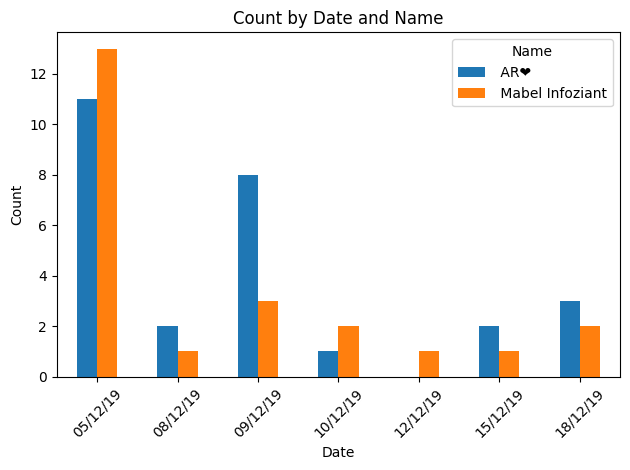

In [85]:
#plt.figure(figsize=(10,20))
#plt.bar(df["Date"],df["Date"].count())
pivot_df.plot(kind='bar')
plt.title('Count by Date and Name')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Flirt Model
You need a clear rule. Common definitions:

High number of messages
Longer messages
Frequent responses
Short response time (engaged)

So “talkative” is not just message count—it’s activity + verbosity

In [106]:
# Message count
msg_count = df.groupby('Name').size()

In [107]:
msg_count

Name
AR❤                27
Mabel Infoziant    23
dtype: int64

In [109]:
# Average Message Length
df["Message_len"] = df['Chat'].apply(len)
avg_len = df.groupby('Name')['Message_len'].mean()

In [111]:
avg_len

Name
AR❤                38.518519
Mabel Infoziant    47.347826
Name: Message_len, dtype: float64

In [112]:
# Total words
df['Word_count'] = df['Chat'].apply(lambda x: len(x.split()))
total_words = df.groupby('Name')['Word_count'].sum()

In [113]:
total_words

Name
AR❤                208
Mabel Infoziant    217
Name: Word_count, dtype: int64

In [115]:
# Message per day
msgs_per_day = df.groupby(['Name', 'Date']).size().groupby('Name').mean()

In [116]:
msgs_per_day

Name
AR❤                4.500000
Mabel Infoziant    3.285714
dtype: float64

In [117]:
#User defined rule to calculate Talkative score
talkative_score = (
    msg_count * 0.4 +
    avg_len * 0.2 +
    total_words * 0.3 +
    msgs_per_day * 0.1
)

In [118]:
talkative_score

Name
AR❤                81.353704
Mabel Infoziant    84.098137
dtype: float64

In [119]:
threshold = talkative_score.mean()
label = talkative_score.apply(lambda x: "Talkative" if x > threshold else "Non-Talkative")

In [121]:
print(label)

Name
AR❤                Non-Talkative
Mabel Infoziant        Talkative
dtype: object




# Time encounters

In [146]:
# Most active date
messages_per_date = df.groupby(df['Date']).size()

most_active_date = messages_per_date.idxmax()
max_messages = messages_per_date.max()

#print("Most active date:", most_active_date)
#print("Message count:", max_messages)

In [147]:
#Most active day of week
import datetime as dt
df['Day_name'] = pd.to_datetime(df['Date']).dt.day_name()

messages_per_day = df.groupby('Day_name').size().sort_values(ascending=False)

#print(messages_per_day)
#print("Most active day:", messages_per_day.idxmax())

In [148]:
messages_per_hour = df.groupby('Time').size()

most_active_hour = messages_per_hour.idxmax()

#print("Most active hour:", most_active_hour)

In [149]:
avg_messages_per_day = messages_per_date.mean()

#print("Avg messages per day:", avg_messages_per_day)

In [152]:
print("Most active date:", most_active_date)
print("Message count:", max_messages)
print("Most active day:", messages_per_day.idxmax())
print("Most active hour:", most_active_hour)
print("Avg messages per day:", avg_messages_per_day)

Most active date: 05/12/19
Message count: 24
Most active day: Sunday
Most active hour:  1:43 pm 
Avg messages per day: 7.142857142857143


In [167]:
media_df = df[df['Chat'].str.contains('media', case=False, na=False)]
media_count = media_df.groupby('Name').size()
if media_df.empty:
    print("Media Count: No shared Media")
else:
    print("Media Count: ", Media_count)


Media Count: No shared Media


In [170]:
deleted_df = df[df['Chat'].str.contains('deleted', case=False, na=False)]
deleted_count = deleted_df.groupby('Name').size()
if deleted_df.empty:
    print("Deleted Count: No delted messages")
else:
    print("Deleted Count: ", deleted_count[0])


Deleted Count:  1


In [171]:
missed_voice_df = df[df['Chat'].str.contains('missed voice call', case=False, na=False)]
missed_voice_count = deleted_df.groupby('Name').size()
if missed_voice_df.empty:
    print("Missed voice call Count: No missed call")
else:
    print("Missed voice call Count: ", missed_voice_count[0])

Missed voice call Count: No missed call


In [172]:
missed_video_df = df[df['Chat'].str.contains('missed video call', case=False, na=False)]
missed_video_count = deleted_df.groupby('Name').size()
if missed_video_df.empty:
    print("Missed video call Count: No missed call")
else:
    print("Missed video call Count: ", missed_video_count[0])

Missed video call Count: No missed call
